<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/014_ab_testing_causal_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## A/B testing: de diferença observada a decisão causal

**Área:** Experimentação e Inferência Causal  
**Tipo de problema:** Experimento randomizado, estimação de efeito e decisão de produto

### Pergunta de estudo

> Como transformar a diferença observada entre controle e tratamento em uma decisão confiável, separando significância estatística, tamanho de efeito, relevância prática e risco para métricas de proteção?

Este estudo simula um experimento A/B de uma nova experiência de checkout em um e-commerce.

### Hipótese

A nova experiência pode:

- aumentar a taxa de conversão;
- elevar a receita por usuário;
- sem aumentar de forma relevante os contatos com suporte.

Como a atribuição de tratamento é aleatória, a diferença média entre os grupos pode ser interpretada como uma estimativa do **efeito causal médio do tratamento (ATE)**, dentro das condições do experimento.

### Métricas

#### Primária
- Conversion Rate.

#### Secundária
- Revenue per User.

#### Guardrail
- Support Contacts per User.

### Componentes do estudo

- desenho experimental;
- análise de poder e tamanho de amostra;
- checagem de randomização;
- efeito absoluto e relativo;
- intervalo de confiança;
- teste de duas proporções;
- bootstrap;
- Welch t-test;
- CUPED;
- correção para múltiplos testes;
- análise exploratória de heterogeneidade;
- regra de decisão estatística + prática.

> O objetivo não é apenas perguntar **“o p-value é menor que 0,05?”**, mas decidir se o efeito é confiável, relevante e operacionalmente aceitável.


## 1. Importações e reprodutibilidade

O notebook utiliza apenas bibliotecas comuns do ecossistema científico do Google Colab.  
As sementes aleatórias são fixadas para permitir reprodução dos resultados.


In [1]:
import math
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

from scipy import stats

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
scikit-learn: 1.6.1


## 2. Desenho do experimento e análise de poder

Antes de observar resultados, definimos:

- nível de significância: `α = 0,05`;
- poder desejado: `80%`;
- conversão de referência: `12%`;
- Minimum Detectable Effect (MDE): **+1,5 ponto percentual**.

O cálculo abaixo usa a aproximação normal para duas proporções independentes.

A análise de poder é importante porque um teste sem amostra suficiente pode não detectar um efeito economicamente relevante, enquanto uma amostra enorme pode tornar estatisticamente significativo um efeito irrelevante na prática.


In [2]:
ALPHA = 0.05
POWER = 0.80
BASELINE_CONVERSION = 0.12
MDE = 0.015

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    numerator = (
        z_alpha * math.sqrt(2 * p_bar * (1 - p_bar))
        + z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))
    ) ** 2
    denominator = (p2 - p1) ** 2
    return math.ceil(numerator / denominator)

required_per_group = sample_size_two_proportions(
    BASELINE_CONVERSION,
    BASELINE_CONVERSION + MDE,
    ALPHA,
    POWER,
)

print(f"Amostra mínima aproximada por grupo: {required_per_group:,}")
print(f"Amostra total aproximada: {2 * required_per_group:,}")


Amostra mínima aproximada por grupo: 7,761
Amostra total aproximada: 15,522


## 3. Geração de um experimento controlado

Para que o notebook seja autocontido, os dados são simulados.

Existe uma variável latente de propensão do usuário que influencia comportamento histórico e resultados atuais. Ela é usada **somente para gerar o mundo simulado** e não entra na análise do experimento.

A randomização do tratamento é independente dessa propensão, reproduzindo a propriedade central de um A/B test bem desenhado.


In [3]:
N = max(12_000, 2 * required_per_group + 500)

segment = rng.choice(
    ["new", "returning", "vip"],
    size=N,
    p=[0.55, 0.35, 0.10],
)

device = rng.choice(
    ["mobile", "desktop"],
    size=N,
    p=[0.72, 0.28],
)

latent_propensity = (
    rng.normal(0, 1, size=N)
    + 0.50 * (segment == "returning")
    + 1.00 * (segment == "vip")
)

pre_revenue = np.maximum(
    0,
    20 + 25 * latent_propensity + rng.normal(0, 10, size=N),
)

pre_sessions = np.maximum(
    1,
    np.round(3 + 1.6 * latent_propensity + rng.normal(0, 1.5, size=N)),
).astype(int)

treatment = rng.binomial(1, 0.50, size=N)

logit_conversion = (
    -2.30
    + 0.55 * latent_propensity
    + 0.12 * (device == "desktop")
    + 0.16 * treatment
)

conversion_probability = 1 / (1 + np.exp(-logit_conversion))
converted = rng.binomial(1, conversion_probability)

expected_order_value = np.exp(
    3.00
    + 0.32 * latent_propensity
    + 0.03 * treatment
)

revenue = np.where(
    converted == 1,
    rng.gamma(shape=4.0, scale=expected_order_value / 4.0),
    0.0,
)

support_rate = np.exp(
    -1.85
    + 0.12 * (segment == "new")
    + 0.01 * treatment
)
support_contacts = rng.poisson(support_rate)

df = pd.DataFrame({
    "segment": segment,
    "device": device,
    "pre_revenue": pre_revenue,
    "pre_sessions": pre_sessions,
    "treatment": treatment,
    "converted": converted,
    "revenue": revenue,
    "support_contacts": support_contacts,
})

df["group"] = np.where(df["treatment"] == 1, "Treatment", "Control")

print(f"Amostras: {len(df):,}")
display(df.head())


Amostras: 16,022


,segment,device,pre_revenue,pre_sessions,treatment,converted,revenue,support_contacts,group
0,returning,desktop,74.834858,4,0,1,23.08545,0,Control
1,new,mobile,0.000000,2,1,0,0.00000,0,Treatment
2,returning,desktop,7.926332,1,1,0,0.00000,0,Treatment
3,returning,desktop,24.186499,3,1,0,0.00000,0,Treatment
4,new,desktop,19.555871,3,1,0,0.00000,1,Treatment


## 4. Checagem de randomização

A randomização não garante que todas as médias serão exatamente iguais, mas deve produzir grupos comparáveis em expectativa.

Usaremos a **Standardized Mean Difference (SMD)** para variáveis pré-tratamento. Como referência prática, valores absolutos abaixo de `0,1` costumam indicar bom equilíbrio.


In [4]:
def standardized_mean_difference(x_control, x_treatment):
    mean_diff = np.mean(x_treatment) - np.mean(x_control)
    pooled_sd = np.sqrt(
        (np.var(x_control, ddof=1) + np.var(x_treatment, ddof=1)) / 2
    )
    return mean_diff / pooled_sd

control = df[df["treatment"] == 0]
treat = df[df["treatment"] == 1]

balance = pd.DataFrame({
    "Control mean": [
        control["pre_revenue"].mean(),
        control["pre_sessions"].mean(),
    ],
    "Treatment mean": [
        treat["pre_revenue"].mean(),
        treat["pre_sessions"].mean(),
    ],
    "SMD": [
        standardized_mean_difference(
            control["pre_revenue"],
            treat["pre_revenue"],
        ),
        standardized_mean_difference(
            control["pre_sessions"],
            treat["pre_sessions"],
        ),
    ],
}, index=["pre_revenue", "pre_sessions"])

print("Tamanho dos grupos:")
display(df["group"].value_counts().to_frame("n"))

print("Balanceamento pré-tratamento:")
display(balance)

print("Distribuição de segmentos:")
display(
    pd.crosstab(
        df["segment"],
        df["group"],
        normalize="columns",
    ).round(3)
)


Tamanho dos grupos:


,n
group,
Treatment,8012
Control,8010


Balanceamento pré-tratamento:


,Control mean,Treatment mean,SMD
pre_revenue,28.869834,29.311290,0.018338
pre_sessions,3.544569,3.591363,0.023294


Distribuição de segmentos:


group,Control,Treatment
segment,,
new,0.554,0.543
returning,0.355,0.352
vip,0.091,0.104


## 5. Métrica primária — Conversion Rate

Para a taxa de conversão calcularemos:

- diferença absoluta em pontos percentuais;
- uplift relativo;
- intervalo de confiança de 95%;
- teste z para duas proporções.

O intervalo de confiança da diferença é especialmente importante: ele mostra a faixa de efeitos compatíveis com os dados, em vez de reduzir toda a análise a um único p-value.


In [5]:
def two_proportion_test(success_c, n_c, success_t, n_t, alpha=0.05):
    p_c = success_c / n_c
    p_t = success_t / n_t
    diff = p_t - p_c

    pooled = (success_c + success_t) / (n_c + n_t)
    se_pooled = math.sqrt(
        pooled * (1 - pooled) * (1 / n_c + 1 / n_t)
    )
    z = diff / se_pooled
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    se_unpooled = math.sqrt(
        p_c * (1 - p_c) / n_c
        + p_t * (1 - p_t) / n_t
    )
    z_crit = stats.norm.ppf(1 - alpha / 2)
    ci = (
        diff - z_crit * se_unpooled,
        diff + z_crit * se_unpooled,
    )

    return {
        "control_rate": p_c,
        "treatment_rate": p_t,
        "absolute_effect": diff,
        "relative_uplift": diff / p_c,
        "z_stat": z,
        "p_value": p_value,
        "ci_low": ci[0],
        "ci_high": ci[1],
    }

conversion_result = two_proportion_test(
    control["converted"].sum(),
    len(control),
    treat["converted"].sum(),
    len(treat),
)

conversion_table = pd.DataFrame({
    "Control": [conversion_result["control_rate"]],
    "Treatment": [conversion_result["treatment_rate"]],
    "Absolute effect": [conversion_result["absolute_effect"]],
    "Relative uplift": [conversion_result["relative_uplift"]],
    "CI 95% low": [conversion_result["ci_low"]],
    "CI 95% high": [conversion_result["ci_high"]],
    "p-value": [conversion_result["p_value"]],
}, index=["Conversion"])

display(
    conversion_table.style.format({
        "Control": "{:.2%}",
        "Treatment": "{:.2%}",
        "Absolute effect": "{:+.2%}",
        "Relative uplift": "{:+.2%}",
        "CI 95% low": "{:+.2%}",
        "CI 95% high": "{:+.2%}",
        "p-value": "{:.4g}",
    })
)


,Control,Treatment,Absolute effect,Relative uplift,CI 95% low,CI 95% high,p-value
Conversion,12.12%,13.94%,+1.82%,+15.01%,+0.78%,+2.86%,0.0006261


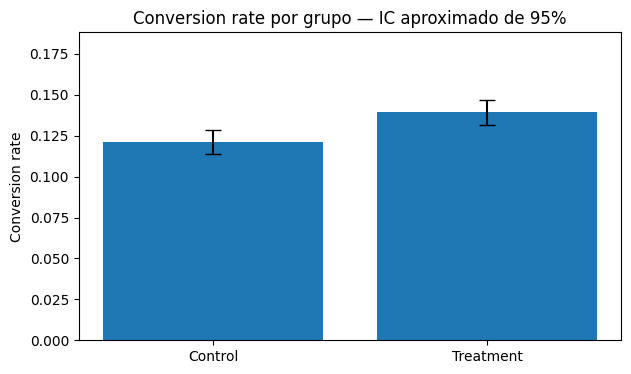

In [6]:
rates = [
    conversion_result["control_rate"],
    conversion_result["treatment_rate"],
]

group_ns = [len(control), len(treat)]
errors = [
    1.96 * math.sqrt(rates[i] * (1 - rates[i]) / group_ns[i])
    for i in range(2)
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Control", "Treatment"], rates, yerr=errors, capsize=6)
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion rate por grupo — IC aproximado de 95%")
ax.set_ylim(0, max(rates) * 1.35)
plt.show()


## 6. Métrica secundária — Revenue per User

Receita por usuário costuma ter distribuição assimétrica e muitos zeros.

Por isso compararemos duas abordagens:

1. **Welch t-test**, que não assume variâncias iguais entre os grupos;
2. **bootstrap**, que estima diretamente a incerteza da diferença média por reamostragem.


In [7]:
revenue_c = control["revenue"].to_numpy()
revenue_t = treat["revenue"].to_numpy()

revenue_diff = revenue_t.mean() - revenue_c.mean()
welch = stats.ttest_ind(
    revenue_t,
    revenue_c,
    equal_var=False,
)

def bootstrap_mean_difference(a, b, n_boot=1500, seed=42):
    local_rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)

    for i in range(n_boot):
        sample_a = local_rng.choice(a, size=len(a), replace=True)
        sample_b = local_rng.choice(b, size=len(b), replace=True)
        diffs[i] = sample_b.mean() - sample_a.mean()

    return diffs

boot_diffs = bootstrap_mean_difference(
    revenue_c,
    revenue_t,
)

boot_ci = np.quantile(
    boot_diffs,
    [0.025, 0.975],
)

revenue_result = pd.DataFrame({
    "Control mean": [revenue_c.mean()],
    "Treatment mean": [revenue_t.mean()],
    "Absolute effect": [revenue_diff],
    "Relative uplift": [revenue_diff / revenue_c.mean()],
    "Bootstrap CI low": [boot_ci[0]],
    "Bootstrap CI high": [boot_ci[1]],
    "Welch p-value": [welch.pvalue],
}, index=["Revenue per User"])

display(
    revenue_result.style.format({
        "Control mean": "${:.3f}",
        "Treatment mean": "${:.3f}",
        "Absolute effect": "${:+.3f}",
        "Relative uplift": "{:+.2%}",
        "Bootstrap CI low": "${:+.3f}",
        "Bootstrap CI high": "${:+.3f}",
        "Welch p-value": "{:.4g}",
    })
)


,Control mean,Treatment mean,Absolute effect,Relative uplift,Bootstrap CI low,Bootstrap CI high,Welch p-value
Revenue per User,$3.185,$3.869,$+0.684,+21.49%,$+0.343,$+1.009,7.413e-05


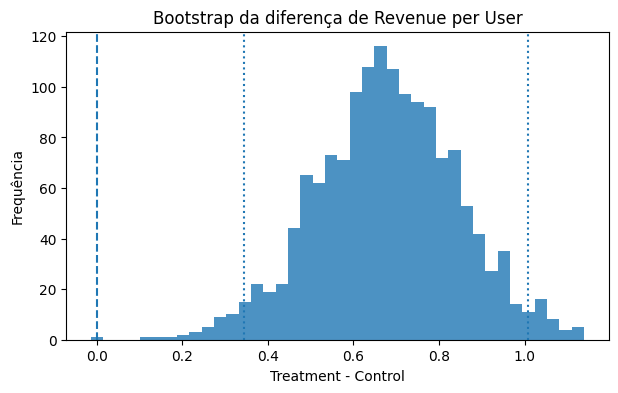

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    boot_diffs,
    bins=40,
    alpha=0.8,
)
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.axvline(boot_ci[0], linestyle=":", linewidth=1.5)
ax.axvline(boot_ci[1], linestyle=":", linewidth=1.5)
ax.set_title("Bootstrap da diferença de Revenue per User")
ax.set_xlabel("Treatment - Control")
ax.set_ylabel("Frequência")
plt.show()


## 7. Redução de variância com CUPED

**CUPED (Controlled-experiment Using Pre-Experiment Data)** usa uma covariável medida antes do experimento e correlacionada com a métrica de interesse.

A transformação é:

\[
Y_{cuped} = Y - \theta(X - \bar{X})
\]

onde:

\[
\theta = \frac{Cov(Y, X)}{Var(X)}
\]

Como `X` é pré-tratamento, a randomização preserva a interpretação causal.  
O objetivo não é alterar o efeito esperado, mas reduzir a variância e aumentar precisão.


In [9]:
x = df["pre_revenue"].to_numpy()
y = df["revenue"].to_numpy()

theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)

df["revenue_cuped"] = (
    df["revenue"]
    - theta * (df["pre_revenue"] - df["pre_revenue"].mean())
)

variance_before = df["revenue"].var(ddof=1)
variance_after = df["revenue_cuped"].var(ddof=1)
variance_reduction = 1 - variance_after / variance_before

cuped_control = df.loc[
    df["treatment"] == 0,
    "revenue_cuped",
]
cuped_treat = df.loc[
    df["treatment"] == 1,
    "revenue_cuped",
]

cuped_test = stats.ttest_ind(
    cuped_treat,
    cuped_control,
    equal_var=False,
)

cuped_summary = pd.DataFrame({
    "Metric": ["Raw revenue", "CUPED revenue"],
    "Control mean": [
        control["revenue"].mean(),
        cuped_control.mean(),
    ],
    "Treatment mean": [
        treat["revenue"].mean(),
        cuped_treat.mean(),
    ],
    "Effect": [
        revenue_diff,
        cuped_treat.mean() - cuped_control.mean(),
    ],
    "Variance": [
        variance_before,
        variance_after,
    ],
})

print(f"Theta CUPED: {theta:.4f}")
print(f"Redução de variância: {variance_reduction:.2%}")
print(f"p-value após CUPED: {cuped_test.pvalue:.4g}")
display(cuped_summary)


Theta CUPED: 0.1089
Redução de variância: 5.75%
p-value após CUPED: 0.0001477


,Metric,Control mean,Treatment mean,Effect,Variance
0,Raw revenue,3.185041,3.869474,0.684432,119.545985
1,CUPED revenue,3.209081,3.845440,0.636359,112.673117


## 8. Guardrail e múltiplos testes

Quanto mais métricas são testadas, maior a probabilidade de encontrar algum resultado “significativo” por acaso.

Aqui aplicaremos o procedimento **Benjamini–Hochberg (BH)** para controlar a False Discovery Rate entre as três métricas principais do estudo.


In [10]:
support_test = stats.ttest_ind(
    treat["support_contacts"],
    control["support_contacts"],
    equal_var=False,
)

support_diff = (
    treat["support_contacts"].mean()
    - control["support_contacts"].mean()
)

raw_tests = pd.DataFrame({
    "metric": [
        "conversion",
        "revenue_per_user",
        "support_contacts",
    ],
    "p_value": [
        conversion_result["p_value"],
        welch.pvalue,
        support_test.pvalue,
    ],
})

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted_ranked = np.empty(m)
    running_min = 1.0

    for i in range(m - 1, -1, -1):
        rank = i + 1
        adjusted = ranked[i] * m / rank
        running_min = min(running_min, adjusted)
        adjusted_ranked[i] = min(running_min, 1.0)

    adjusted = np.empty(m)
    adjusted[order] = adjusted_ranked
    return adjusted

raw_tests["p_value_bh"] = benjamini_hochberg(
    raw_tests["p_value"],
)
raw_tests["significant_bh_5pct"] = (
    raw_tests["p_value_bh"] < 0.05
)

display(raw_tests)

print(
    "Support contacts — efeito:",
    f"{support_diff:+.4f}",
    "| p-value:",
    f"{support_test.pvalue:.4g}",
)


,metric,p_value,p_value_bh,significant_bh_5pct
0,conversion,0.000626,0.000939,True
1,revenue_per_user,0.000074,0.000222,True
2,support_contacts,0.571755,0.571755,False


Support contacts — efeito: +0.0037 | p-value: 0.5718


## 9. Heterogeneidade exploratória

Um efeito médio pode esconder diferenças entre segmentos.

Vamos estimar o efeito de conversão em `new`, `returning` e `vip`.

**Importante:** como o experimento não foi dimensionado para provar efeitos diferentes em cada subgrupo, esta análise deve ser tratada como exploratória. Comparações de segmentos exigem cuidado com poder estatístico e múltiplos testes.


In [11]:
segment_rows = []

for seg, part in df.groupby("segment"):
    c = part[part["treatment"] == 0]
    t = part[part["treatment"] == 1]

    result = two_proportion_test(
        c["converted"].sum(),
        len(c),
        t["converted"].sum(),
        len(t),
    )

    segment_rows.append({
        "segment": seg,
        "n": len(part),
        "control_rate": result["control_rate"],
        "treatment_rate": result["treatment_rate"],
        "effect": result["absolute_effect"],
        "ci_low": result["ci_low"],
        "ci_high": result["ci_high"],
        "p_value": result["p_value"],
    })

segment_effects = pd.DataFrame(segment_rows)
display(
    segment_effects.style.format({
        "control_rate": "{:.2%}",
        "treatment_rate": "{:.2%}",
        "effect": "{:+.2%}",
        "ci_low": "{:+.2%}",
        "ci_high": "{:+.2%}",
        "p_value": "{:.4g}",
    })
)


,segment,n,control_rate,treatment_rate,effect,ci_low,ci_high,p_value
0,new,8788,10.91%,12.32%,+1.41%,+0.07%,+2.75%,0.03973
1,returning,5667,12.83%,15.37%,+2.54%,+0.73%,+4.35%,0.006018
2,vip,1567,16.71%,17.56%,+0.85%,-2.89%,+4.59%,0.6561


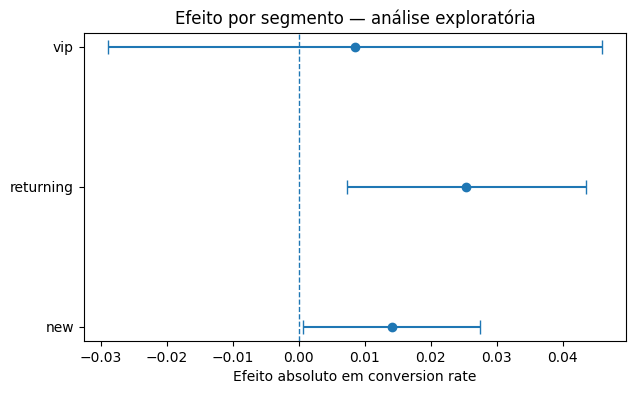

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(segment_effects))
effects = segment_effects["effect"].to_numpy()
lower = effects - segment_effects["ci_low"].to_numpy()
upper = segment_effects["ci_high"].to_numpy() - effects

ax.errorbar(
    effects,
    y_pos,
    xerr=[lower, upper],
    fmt="o",
    capsize=5,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(segment_effects["segment"])
ax.set_xlabel("Efeito absoluto em conversion rate")
ax.set_title("Efeito por segmento — análise exploratória")
plt.show()


## 10. Da significância estatística à decisão

Uma regra de decisão deve ser definida de forma explícita.

Neste estudo, consideraremos:

- métrica primária significativa após o teste;
- aumento de conversão de pelo menos **+1,0 p.p.**;
- receita por usuário não pode piorar;
- contatos de suporte não podem aumentar mais que **+0,03 por usuário**.

A regra é apenas um exemplo. Em um experimento real, thresholds devem vir de contexto econômico, risco e estratégia.


In [13]:
PRACTICAL_CONVERSION_THRESHOLD = 0.010
MAX_SUPPORT_INCREASE = 0.030

primary_significant = (
    conversion_result["p_value"] < ALPHA
)
conversion_practical = (
    conversion_result["absolute_effect"]
    >= PRACTICAL_CONVERSION_THRESHOLD
)
revenue_not_worse = revenue_diff >= 0
guardrail_ok = support_diff <= MAX_SUPPORT_INCREASE

decision = (
    primary_significant
    and conversion_practical
    and revenue_not_worse
    and guardrail_ok
)

decision_table = pd.DataFrame({
    "Criterion": [
        "Primary metric statistically significant",
        "Conversion effect >= +1.0 p.p.",
        "Revenue per user not worse",
        "Support guardrail respected",
    ],
    "Passed": [
        primary_significant,
        conversion_practical,
        revenue_not_worse,
        guardrail_ok,
    ],
})

display(decision_table)
print(
    "DECISÃO:",
    "RECOMENDAR ROLLOUT" if decision
    else "NÃO RECOMENDAR ROLLOUT AINDA",
)


,Criterion,Passed
0,Primary metric statistically significant,True
1,Conversion effect >= +1.0 p.p.,True
2,Revenue per user not worse,True
3,Support guardrail respected,True


DECISÃO: RECOMENDAR ROLLOUT


## 11. Conclusões

Este estudo mostra que um A/B test confiável envolve mais do que comparar duas médias.

O fluxo completo inclui:

1. definir hipótese e métrica primária antes de observar os resultados;
2. dimensionar a amostra com base em poder estatístico e MDE;
3. verificar se a randomização produziu grupos comparáveis;
4. estimar **tamanho de efeito + intervalo de confiança**;
5. analisar métricas secundárias e guardrails;
6. considerar assimetria das distribuições e usar bootstrap quando apropriado;
7. reduzir variância com dados pré-experimento quando houver covariáveis úteis;
8. controlar o risco de falsos positivos em múltiplos testes;
9. separar significância estatística de relevância prática;
10. transformar evidência estatística em uma regra explícita de decisão.

### Interpretação causal

Neste cenário, o tratamento foi randomizado. Portanto, sob consistência do experimento e ausência de interferência relevante entre usuários, a diferença média entre grupos identifica o efeito causal médio da nova experiência.

### Limitações

- os dados são simulados;
- não modelamos non-compliance;
- não tratamos testes sequenciais ou optional stopping;
- heterogeneidade por segmento é apenas exploratória;
- não há interferência entre unidades;
- resultados de um experimento real ainda dependem de validade externa e contexto de negócio.

### Próximos passos possíveis

Em cenários observacionais, onde o tratamento não é randomizado, seriam necessárias técnicas adicionais como:

- propensity scores;
- inverse probability weighting;
- matching;
- doubly robust estimation;
- difference-in-differences;
- synthetic controls;
- instrumental variables.

Essas técnicas respondem a um problema diferente: recuperar causalidade quando a randomização não está disponível.
